# DS207 Final Project - Predicting Readmission Rate for Diabetic Patients Using Machine Learning
#### Contributor: Colin Frishberg (cpfrish@berkeley.edu)

### Notebook Structure:

1.  Create compelling **data visualizations**.
2.  **Input:** Load raw and processed data from data files.
3.  Build, train, and evaluate the **Transformer Model**.
4.  **Output:** Save the visualizations to html files in the '/results' directory
5.  **Output:** Save the trained Transformer model to `/results/transformer.h5`.
6.  **Output:** Save the statistics from the transformer model to `/results/stats_transformer.csv`.

## 1. Notebook Imports

### 1.1 Import basic and necessary libraries:

In [1]:
# Basic imports
import numpy as np
import warnings
import pandas as pd
import tensorflow as tf
from matplotlib import pyplot as plt
from tensorflow import keras
import altair as alt

alt.data_transformers.enable("vegafusion")

# Compress all warnings
warnings.filterwarnings("ignore")

2025-12-07 21:02:54.129407: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-07 21:02:54.130020: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-07 21:02:54.134014: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-07 21:02:54.160793: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-07 21:02:54.200125: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been 

### 1.2 Import datasets:

In [ ]:
# Load raw data set
df = pd.read_csv("../data/diabetic_data.csv")

# Load cleaned data set (from colin_dev)
df_cleaned_dev = pd.read_csv("../data/diabetic_data_cleaned_encoded.csv")

# Load train, val, test splits (from Rahil's notebook)
df_train = pd.read_csv("../results/train.csv")
df_val = pd.read_csv("../results/val.csv")
df_test = pd.read_csv("../results/test.csv")

# Load colin_final data splits (for model development)
df_train_final = pd.read_csv("../data/X_train_scaled.csv")
df_val_final = pd.read_csv("../data/X_val_scaled.csv")
df_test_final = pd.read_csv("../data/X_test_scaled.csv")
df_y_train_final = pd.read_csv("../data/y_train.csv")
df_y_val_final = pd.read_csv("../data/y_val.csv")
df_y_test_dev = pd.read_csv("../data/y_test.csv")

# Combine train, val, test into a single dataframe for visualization
df_combined_clean = pd.concat([df_train, df_val, df_test], axis=0)

In [3]:
# Display shape of raw and cleaned data sets
print(f"Raw data set shape: {df.shape}")
print(f"Cleaned data set shape: {df_cleaned_dev.shape}")
print(f"Combined data set shape: {df_combined_clean.shape}")
print(f"Train split shape: {df_train.shape}")
print(f"Validation split shape: {df_val.shape}")
print(f"Test split shape: {df_test.shape}")

Raw data set shape: (101766, 50)
Cleaned data set shape: (67086, 69)
Combined data set shape: (71518, 43)
Train split shape: (42910, 43)
Validation split shape: (14304, 43)
Test split shape: (14304, 43)


## 2. Visualization

In [4]:
# Install vegafusion for Altair visualizations
# %pip install "vegafusion[embed]>=1.5.0"
# Install vl-convert-python for Altair visualizations
# %pip install "vl-convert-python>=1.6.0"

This section is broken into two parts. One being Ditributions of the data, the second being Statistical Analysis using assumptions of Logistic Regression for a Binary Classification problem.  

#### Target Variable Distribution

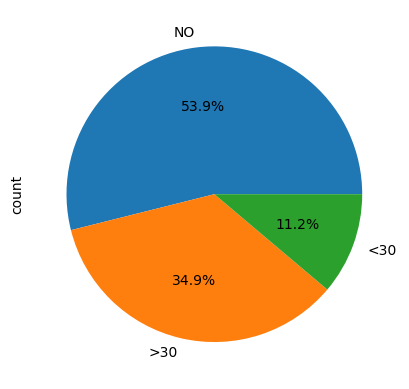

In [5]:
# Visualization of readmission distribution
df["readmitted"].value_counts() / len(df)
counts = df["readmitted"].value_counts()

percentages = counts * 100 / len(df)

fig, ax = plt.subplots()
percentages.plot(kind="pie", ax=ax, autopct="%1.1f%%")
plt.show()

In [6]:
# Define continuous features
continuous_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "age_mid",
]

#### Kernel Density Estimates plots

In [7]:
def create_kde_plots(df, kde_vars, ncols=2):
    """
    Generates and combines KDE plots into a grid for given features

    Args:
        df (pd.Dataframe)
        kde_vars(list): List of columns to plot
        ncols(int): Number of columns in the grid

    Returns:
        alt.vconcat: Grid of KDE plots
    """
    charts = []
    for var in kde_vars:
        chart = (
            alt.Chart(df)
            .transform_density(
                density=var,
                as_=[var, "Density"],  # The output fields for the value and its density
                groupby=["readmitted"],
            )
            .mark_area(opacity=0.5)
            .encode(
                x=alt.X(f"{var}:Q", title=var.replace("_", " ").title()),
                y=alt.Y("Density:Q"),
                # Color by the 'readmitted' class aka target variable
                color=alt.Color("readmitted:N", title="Readmitted Class"),
            )
            .properties(
                title=f"Distribution of {var.replace('_', ' ').title()}",
                width=300,
                height=200,
            )
        )
        charts.append(chart)

        # Grid creations
        rows = [
            alt.hconcat(*charts[i : i + ncols]) for i in range(0, len(charts), ncols)
        ]
    # Combine all created charts vertically and return them
    return alt.vconcat(*rows)

#### Box Plots

In [8]:
# Box Plots for distributions of key predictors to outcome
def create_box_plots(df, continuous_features):
    """
    Generates and combines box plots into a grid for given features

    Args:
        df (pd.Dataframe)
        continuous_features(list): List of columns to plot
    """
    box_plots = []
    for feature in continuous_features:
        # Create box plot for each feature against readmission
        chart = (
            alt.Chart(df)
            .mark_boxplot()
            .encode(
                x=alt.X(
                    "readmitted:N", title="Readmitted Class (0: NO, 1: >30, 2: <30)"
                ),
                y=alt.Y(f"{feature}:Q", title=feature.replace("_", " ").title()),
                color=alt.Color("readmitted:N", title="Readmitted Class").scale(
                    scheme="category20"
                ),
                tooltip=["readmitted", feature],
            )
            .properties(
                title=f"Box Plot of {feature.replace('_', ' ').title()} by Readmission Status",
                width=300,
                height=200,
            )
        )
        box_plots.append(chart)

    # Arrange the box plots in a grid
    ncols = 3
    rows = [
        alt.hconcat(*box_plots[i : i + ncols]) for i in range(0, len(box_plots), ncols)
    ]
    alt.vconcat(*rows)
    return alt.vconcat(*rows)

#### Violin Plots

In [9]:
def create_violin_plots(df, continuous_features):
    """
    Generates and combines violin plots into a grid for given features

    Args:
        df (pd.Dataframe)
        continuous_features(list): List of columns to plot
    """
    # Create violin plots for each continuous feature

    violin_plots = []
    for feature in continuous_features:
        chart = (
            alt.Chart(df)
            .transform_density(
                density=feature, as_=[feature, "density"], groupby=["readmitted"]
            )
            .mark_area(orient="horizontal")
            .encode(
                y=alt.Y(f"{feature}:Q", title=feature.replace("_", " ").title()),
                x=alt.X(
                    "density:Q",
                    stack="center",
                    impute=None,
                    title=None,
                    axis=alt.Axis(labels=False, values=[0], grid=False, ticks=True),
                ),
                color=alt.Color(
                    "readmitted:N", legend=alt.Legend(title="Readmitted")
                ).scale(scheme="tableau20"),
            )
            .properties(
                title=f"Distribution of {feature.replace('_', ' ').title()} by Readmission",
                width=300,
                height=250,
            )
        )
        violin_plots.append(chart)

    # Arrange the violin plots in a grid
    ncols = 4
    rows_violin = [
        alt.hconcat(*violin_plots[i : i + ncols])
        for i in range(0, len(violin_plots), ncols)
    ]
    final_violin_chart = alt.vconcat(*rows_violin)
    return final_violin_chart


## 2.1 Statistical EDA

### 2.1.1 Skewness Analysis

SKEWNESS COMPARISON: RAW vs RAHIL vs COLIN

1. Raw Data:
   Total features: 13
   Mean |skewness|: 3.581
   Highly skewed (|skew| > 1): 9
   Moderately skewed (|skew| > 0.5): 11

2. Rahil's Processed Data:
   Total features: 42
   Mean |skewness|: 33.963
   Highly skewed (|skew| > 1): 32
   Moderately skewed (|skew| > 0.5): 34

3. Colin's Dev Processed Data:
   Total features: 68
   Mean |skewness|: 21.558
   Highly skewed (|skew| > 1): 53
   Moderately skewed (|skew| > 0.5): 57


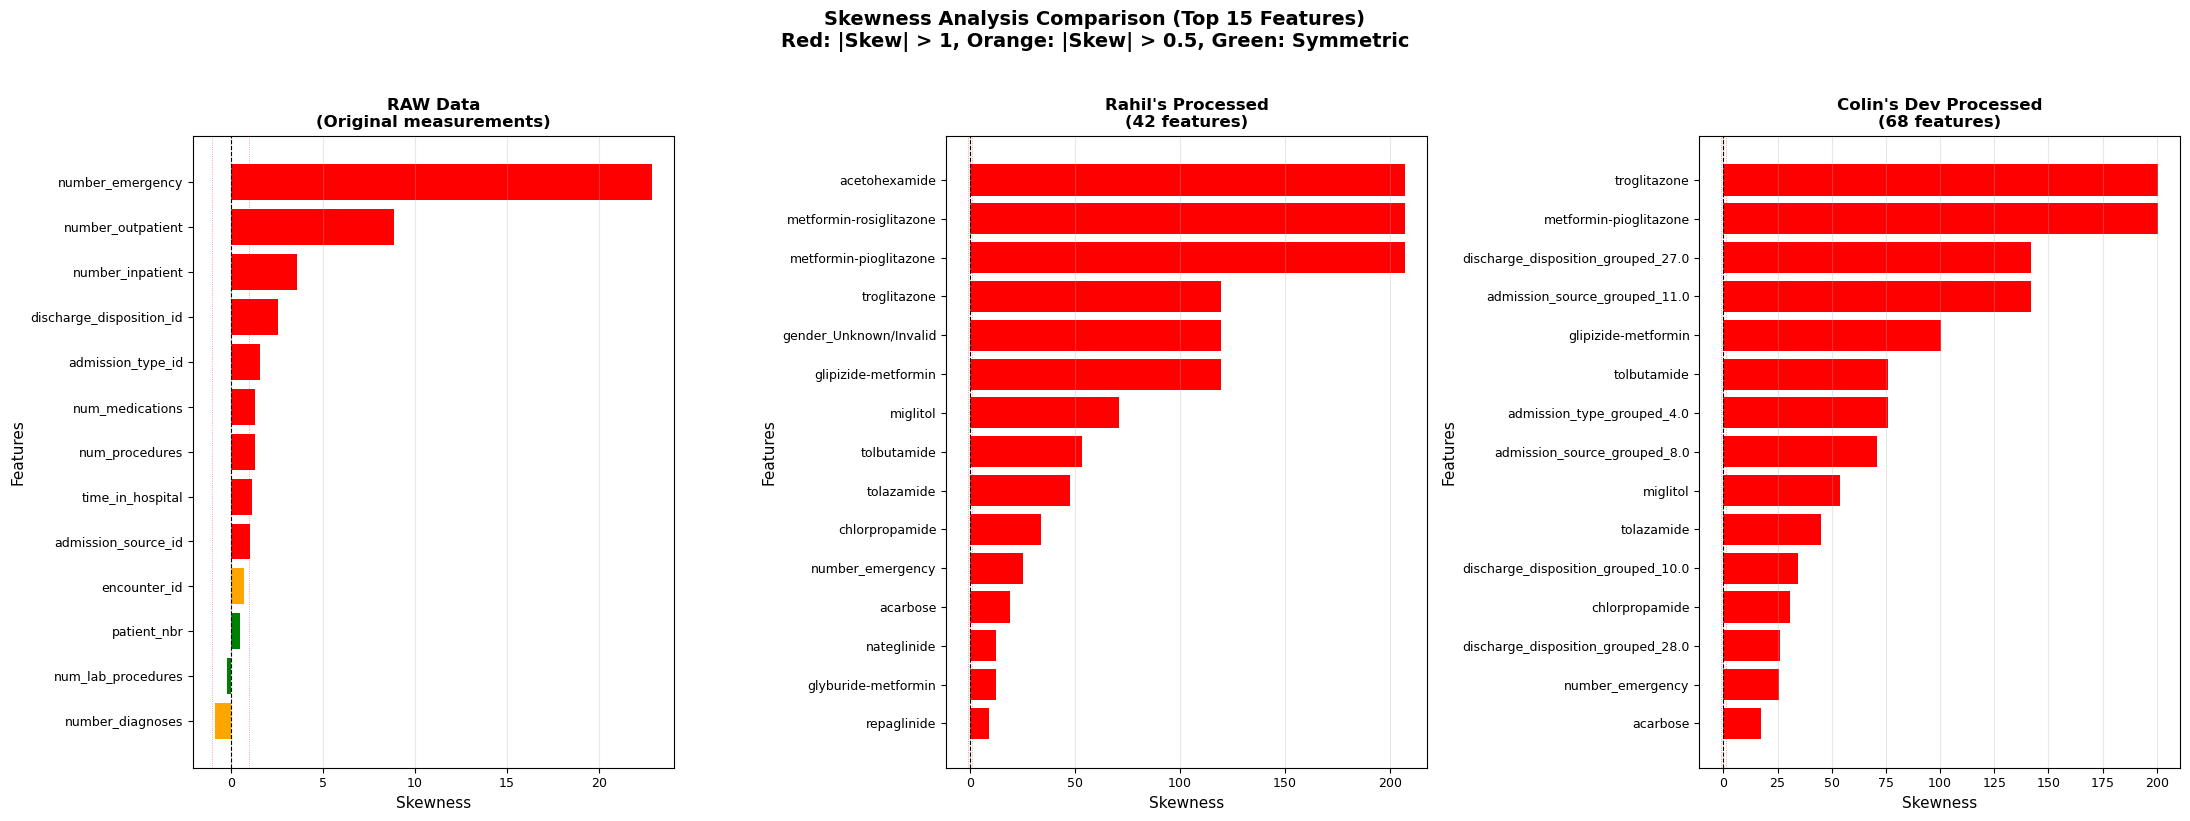

In [10]:
from scipy.stats import skew
import seaborn as sns

# Get numerical columns from raw data
raw_numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'readmitted' in raw_numerical_cols:
    raw_numerical_cols.remove('readmitted')

# Get numerical columns from Rahil's TRAINING data
rahil_numerical_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
if 'readmitted' in rahil_numerical_cols:
    rahil_numerical_cols.remove('readmitted')

# Get numerical columns from Colin's dev TRAINING data
colin_numerical_cols = df_train_dev.select_dtypes(include=[np.number]).columns.tolist()
if 'readmitted' in colin_numerical_cols:
    colin_numerical_cols.remove('readmitted')

# Calculate skewness for RAW data
skewness_raw = []
for col in raw_numerical_cols:
    skew_value = skew(df[col].dropna())
    skewness_raw.append({'Feature': col, 'Skewness': skew_value})

skewness_raw_df = pd.DataFrame(skewness_raw).sort_values('Skewness', ascending=False)

# Calculate skewness for RAHIL's TRAINING data
skewness_rahil = []
for col in rahil_numerical_cols:
    skew_value = skew(df_train[col].dropna())
    skewness_rahil.append({'Feature': col, 'Skewness': skew_value})
skewness_rahil_df = pd.DataFrame(skewness_rahil).sort_values('Skewness', ascending=False)

# Calculate skewness for COLIN's dev TRAINING data
skewness_colin = []
for col in colin_numerical_cols:
    skew_value = skew(df_train_dev[col].dropna())
    skewness_colin.append({'Feature': col, 'Skewness': skew_value})
skewness_colin_df = pd.DataFrame(skewness_colin).sort_values('Skewness', ascending=False)

# Comparison statistics
print("="*80)
print("SKEWNESS COMPARISON: RAW vs RAHIL vs COLIN")
print("="*80)

print(f"\n1. Raw Data:")
print(f"   Total features: {len(skewness_raw_df)}") 
print(f"   Mean |skewness|: {skewness_raw_df['Skewness'].abs().mean():.3f}")
print(f"   Highly skewed (|skew| > 1): {(skewness_raw_df['Skewness'].abs() > 1).sum()}")
print(f"   Moderately skewed (|skew| > 0.5): {(skewness_raw_df['Skewness'].abs() > 0.5).sum()}")

print(f"\n2. Rahil's Processed Data:")
print(f"   Total features: {len(skewness_rahil_df)}")
print(f"   Mean |skewness|: {skewness_rahil_df['Skewness'].abs().mean():.3f}")
print(f"   Highly skewed (|skew| > 1): {(skewness_rahil_df['Skewness'].abs() > 1).sum()}")
print(f"   Moderately skewed (|skew| > 0.5): {(skewness_rahil_df['Skewness'].abs() > 0.5).sum()}")

print(f"\n3. Colin's Dev Processed Data:")
print(f"   Total features: {len(skewness_colin_df)}")
print(f"   Mean |skewness|: {skewness_colin_df['Skewness'].abs().mean():.3f}")
print(f"   Highly skewed (|skew| > 1): {(skewness_colin_df['Skewness'].abs() > 1).sum()}")
print(f"   Moderately skewed (|skew| > 0.5): {(skewness_colin_df['Skewness'].abs() > 0.5).sum()}")

print("="*80)

# Create three-panel comparison
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 8))

# Plot RAW data skewness (top 15)
top_raw = skewness_raw_df.head(15)
colors_raw = ['red' if abs(x) > 1 else 'orange' if abs(x) > 0.5 else 'green' 
              for x in top_raw['Skewness']]
ax1.barh(top_raw['Feature'], top_raw['Skewness'], color=colors_raw)
ax1.set_xlabel('Skewness', fontsize=11)
ax1.set_ylabel('Features', fontsize=11)
ax1.set_title('RAW Data\n(Original measurements)', fontsize=12, fontweight='bold')
ax1.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax1.axvline(x=1, color='red', linestyle=':', linewidth=0.6, alpha=0.5)
ax1.axvline(x=-1, color='red', linestyle=':', linewidth=0.6, alpha=0.5)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)
ax1.tick_params(axis='both', labelsize=9)

# Plot RAHIL's processed data skewness (top 15)
top_rahil = skewness_rahil_df.head(15)
colors_rahil = ['red' if abs(x) > 1 else 'orange' if abs(x) > 0.5 else 'green' 
                for x in top_rahil['Skewness']]
ax2.barh(top_rahil['Feature'], top_rahil['Skewness'], color=colors_rahil)
ax2.set_xlabel('Skewness', fontsize=11)
ax2.set_ylabel('Features', fontsize=11)
ax2.set_title("Rahil's Processed\n(42 features)", fontsize=12, fontweight='bold')
ax2.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax2.axvline(x=1, color='red', linestyle=':', linewidth=0.6, alpha=0.5)
ax2.axvline(x=-1, color='red', linestyle=':', linewidth=0.6, alpha=0.5)
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)
ax2.tick_params(axis='both', labelsize=9)

# Plot COLIN's dev processed data skewness (top 15)
top_colin = skewness_colin_df.head(15)
colors_colin = ['red' if abs(x) > 1 else 'orange' if abs(x) > 0.5 else 'green' 
                for x in top_colin['Skewness']]
ax3.barh(top_colin['Feature'], top_colin['Skewness'], color=colors_colin)
ax3.set_xlabel('Skewness', fontsize=11)
ax3.set_ylabel('Features', fontsize=11)
ax3.set_title("Colin's Dev Processed\n(68 features)", fontsize=12, fontweight='bold')
ax3.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax3.axvline(x=1, color='red', linestyle=':', linewidth=0.6, alpha=0.5)
ax3.axvline(x=-1, color='red', linestyle=':', linewidth=0.6, alpha=0.5)
ax3.invert_yaxis()
ax3.grid(axis='x', alpha=0.3)
ax3.tick_params(axis='both', labelsize=9)

fig.suptitle('Skewness Analysis Comparison (Top 15 Features)\nRed: |Skew| > 1, Orange: |Skew| > 0.5, Green: Symmetric', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 2.1.2 Variance Inflation Factor (VIF) Analysis

Comparing 13 features that exist in raw data: ['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
Calculating VIF for raw data...
Calculating VIF for Rahil's training data (8 common features)...
Calculating VIF for Colin's dev training data (8 common features)...
VIF COMPARISON: RAW vs RAHIL vs COLIN

1. Raw Data:
   Total features: 13
   Mean VIF: 3.46
   Max VIF: 12.79
   High multicollinearity (VIF > 10): 1
   Moderate multicollinearity (VIF > 5): 3

2. Rahil's Processed Data:
   Total features: 8
   Mean VIF: 3.24
   Max VIF: 6.18
   High multicollinearity (VIF > 10): 0
   Moderate multicollinearity (VIF > 5): 3

3. Colin's Dev Processed Data:
   Total features: 8
   Mean VIF: 3.03
   Max VIF: 6.10
   High multicollinearity (VIF > 10): 0
   Moderate multicollinearity (VIF >

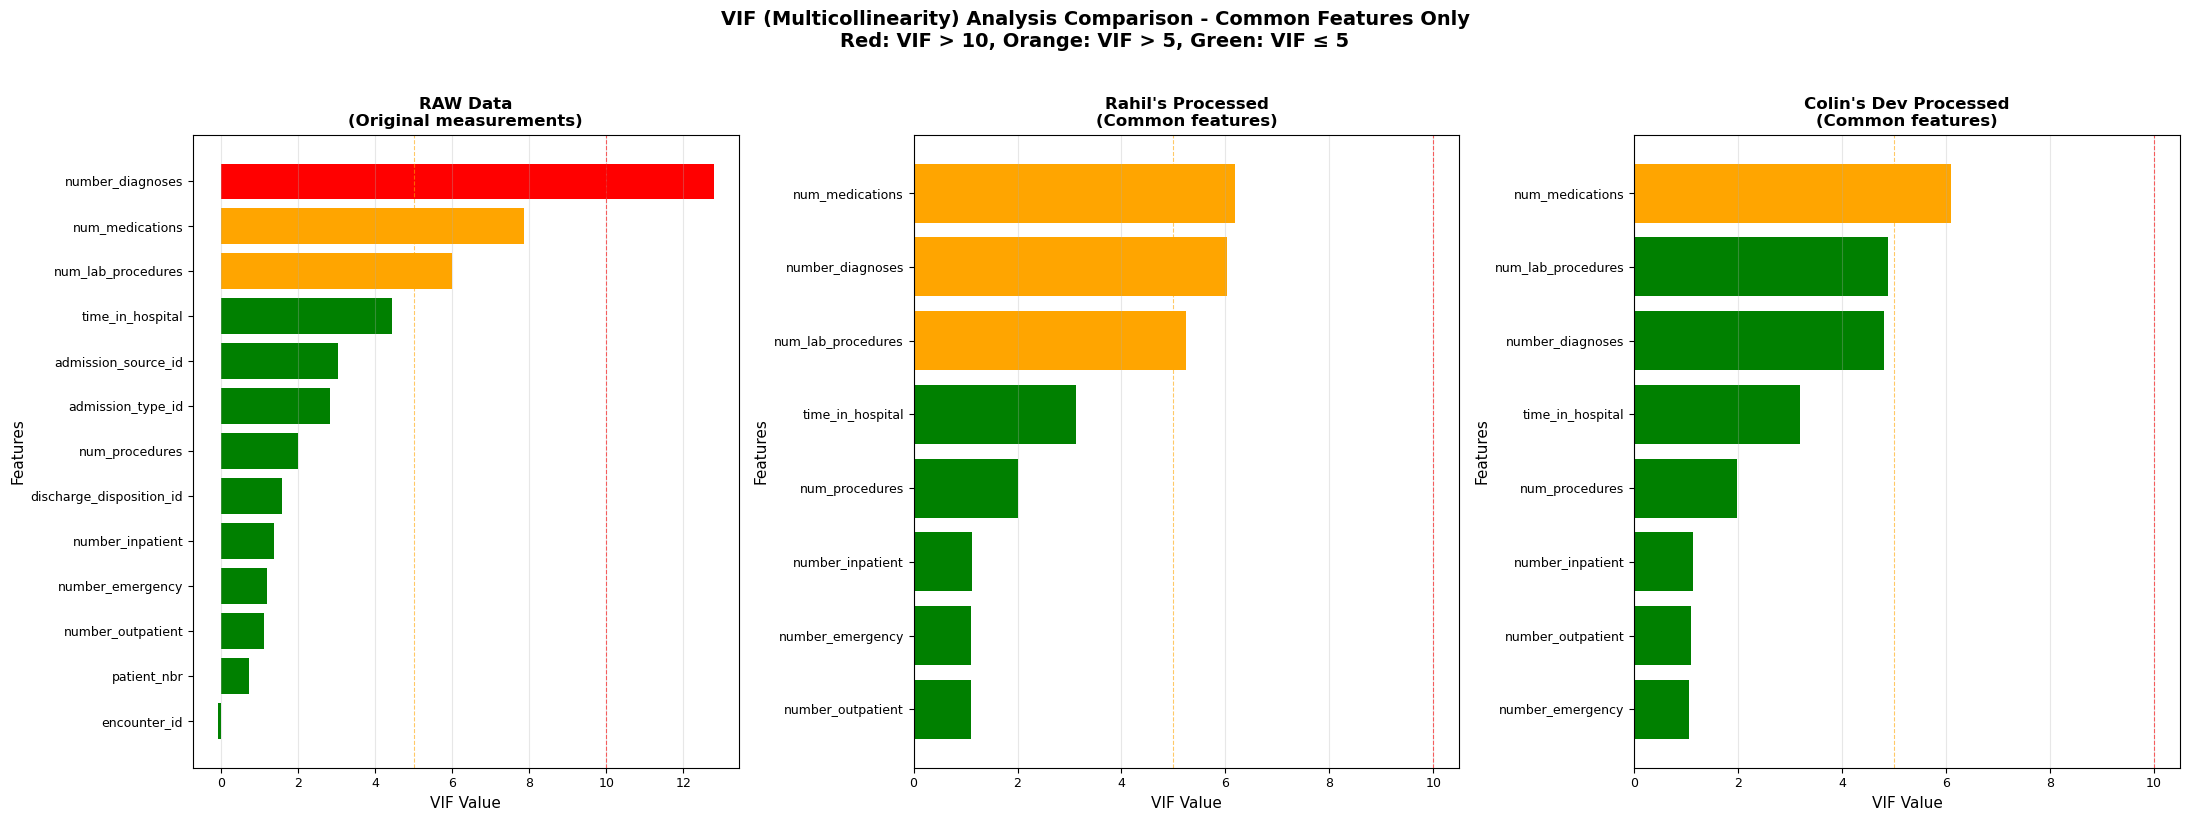

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Use only features that exist in RAW data for apples-to-apples comparison
common_features = raw_numerical_cols.copy()
print(f"Comparing {len(common_features)} features that exist in raw data: {common_features}")

# Prepare RAW data for VIF calculation
X_vif_raw = df[common_features].copy()
X_vif_raw = X_vif_raw.loc[:, X_vif_raw.std() > 0]
if len(X_vif_raw) > 10000:
    X_vif_raw = X_vif_raw.sample(n=10000, random_state=34)
X_vif_raw = X_vif_raw.dropna()

# Calculate VIF for RAW data
print("Calculating VIF for raw data...")
vif_raw_data = []
for i, col in enumerate(X_vif_raw.columns):
    try:
        vif = variance_inflation_factor(X_vif_raw.values, i)
        vif_raw_data.append({'Feature': col, 'VIF': vif})
    except:
        vif_raw_data.append({'Feature': col, 'VIF': np.nan})

vif_raw_df = pd.DataFrame(vif_raw_data).sort_values('VIF', ascending=False)

# Prepare RAHIL's TRAINING data for VIF calculation (only common features)
rahil_common = [col for col in common_features if col in df_train.columns]
X_vif_rahil = df_train[rahil_common].copy()
X_vif_rahil = X_vif_rahil.loc[:, X_vif_rahil.std() > 0]
if len(X_vif_rahil) > 10000:
    X_vif_rahil = X_vif_rahil.sample(n=10000, random_state=34)
X_vif_rahil = X_vif_rahil.dropna()

# Calculate VIF for RAHIL's TRAINING data
print(f"Calculating VIF for Rahil's training data ({len(rahil_common)} common features)...")
vif_rahil_data = []
for i, col in enumerate(X_vif_rahil.columns):
    try:
        vif = variance_inflation_factor(X_vif_rahil.values, i)
        vif_rahil_data.append({'Feature': col, 'VIF': vif})
    except:
        vif_rahil_data.append({'Feature': col, 'VIF': np.nan})
vif_rahil_df = pd.DataFrame(vif_rahil_data).sort_values('VIF', ascending=False)

# Prepare COLIN's dev TRAINING data for VIF calculation (only common features)
colin_common = [col for col in common_features if col in df_train_dev.columns]
X_vif_colin = df_train_dev[colin_common].copy()
X_vif_colin = X_vif_colin.loc[:, X_vif_colin.std() > 0]
if len(X_vif_colin) > 10000:
    X_vif_colin = X_vif_colin.sample(n=10000, random_state=34)
X_vif_colin = X_vif_colin.dropna()

# Calculate VIF for COLIN's TRAINING data
print(f"Calculating VIF for Colin's dev training data ({len(colin_common)} common features)...")
vif_colin_data = []
for i, col in enumerate(X_vif_colin.columns):
    try:
        vif = variance_inflation_factor(X_vif_colin.values, i)
        vif_colin_data.append({'Feature': col, 'VIF': vif})
    except:
        vif_colin_data.append({'Feature': col, 'VIF': np.nan})
vif_colin_df = pd.DataFrame(vif_colin_data).sort_values('VIF', ascending=False)

# Comparison statistics
print("="*80)
print("VIF COMPARISON: RAW vs RAHIL vs COLIN")
print("="*80)

print(f"\n1. Raw Data:")
print(f"   Total features: {len(vif_raw_df)}")
print(f"   Mean VIF: {vif_raw_df['VIF'].mean():.2f}")
print(f"   Max VIF: {vif_raw_df['VIF'].max():.2f}")
print(f"   High multicollinearity (VIF > 10): {(vif_raw_df['VIF'] > 10).sum()}")
print(f"   Moderate multicollinearity (VIF > 5): {(vif_raw_df['VIF'] > 5).sum()}")

print(f"\n2. Rahil's Processed Data:")
print(f"   Total features: {len(vif_rahil_df)}")
print(f"   Mean VIF: {vif_rahil_df['VIF'].mean():.2f}")
print(f"   Max VIF: {vif_rahil_df['VIF'].max():.2f}")
print(f"   High multicollinearity (VIF > 10): {(vif_rahil_df['VIF'] > 10).sum()}")
print(f"   Moderate multicollinearity (VIF > 5): {(vif_rahil_df['VIF'] > 5).sum()}")

print(f"\n3. Colin's Dev Processed Data:")
print(f"   Total features: {len(vif_colin_df)}")
print(f"   Mean VIF: {vif_colin_df['VIF'].mean():.2f}")
print(f"   Max VIF: {vif_colin_df['VIF'].max():.2f}")
print(f"   High multicollinearity (VIF > 10): {(vif_colin_df['VIF'] > 10).sum()}")
print(f"   Moderate multicollinearity (VIF > 5): {(vif_colin_df['VIF'] > 5).sum()}")
print("="*80)

print("\n NOTE: Comparing only the features present in RAW data for apples-to-apples comparison.")
print("This excludes one-hot encoded categorical variables that cause infinite VIF.")
print("="*80)

# Create three-panel comparison
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 8))

# Plot RAW data VIF (all features since we filtered to common ones)
colors_raw = ['red' if x > 10 else 'orange' if x > 5 else 'green' 
              for x in vif_raw_df['VIF'].fillna(0)]
ax1.barh(vif_raw_df['Feature'], vif_raw_df['VIF'], color=colors_raw)
ax1.set_xlabel('VIF Value', fontsize=11)
ax1.set_ylabel('Features', fontsize=11)
ax1.set_title('RAW Data\n(Original measurements)', fontsize=12, fontweight='bold')
ax1.axvline(x=5, color='orange', linestyle='--', linewidth=0.8, alpha=0.6)
ax1.axvline(x=10, color='red', linestyle='--', linewidth=0.8, alpha=0.6)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)
ax1.tick_params(axis='both', labelsize=9)

# Plot RAHIL's processed data VIF (all common features)
colors_rahil = ['red' if x > 10 else 'orange' if x > 5 else 'green' 
                for x in vif_rahil_df['VIF'].fillna(0)]
ax2.barh(vif_rahil_df['Feature'], vif_rahil_df['VIF'], color=colors_rahil)
ax2.set_xlabel('VIF Value', fontsize=11)
ax2.set_ylabel('Features', fontsize=11)
ax2.set_title("Rahil's Processed\n(Common features)", fontsize=12, fontweight='bold')
ax2.axvline(x=5, color='orange', linestyle='--', linewidth=0.8, alpha=0.6)
ax2.axvline(x=10, color='red', linestyle='--', linewidth=0.8, alpha=0.6)
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)
ax2.tick_params(axis='both', labelsize=9)

# Plot COLIN's dev processed data VIF (all common features)
colors_colin = ['red' if x > 10 else 'orange' if x > 5 else 'green' 
                for x in vif_colin_df['VIF'].fillna(0)]
ax3.barh(vif_colin_df['Feature'], vif_colin_df['VIF'], color=colors_colin)
ax3.set_xlabel('VIF Value', fontsize=11)
ax3.set_ylabel('Features', fontsize=11)
ax3.set_title("Colin's Dev Processed\n(Common features)", fontsize=12, fontweight='bold')
ax3.axvline(x=5, color='orange', linestyle='--', linewidth=0.8, alpha=0.6)
ax3.axvline(x=10, color='red', linestyle='--', linewidth=0.8, alpha=0.6)
ax3.invert_yaxis()
ax3.grid(axis='x', alpha=0.3)
ax3.tick_params(axis='both', labelsize=9)

fig.suptitle('VIF (Multicollinearity) Analysis Comparison - Common Features Only\nRed: VIF > 10, Orange: VIF > 5, Green: VIF ≤ 5', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

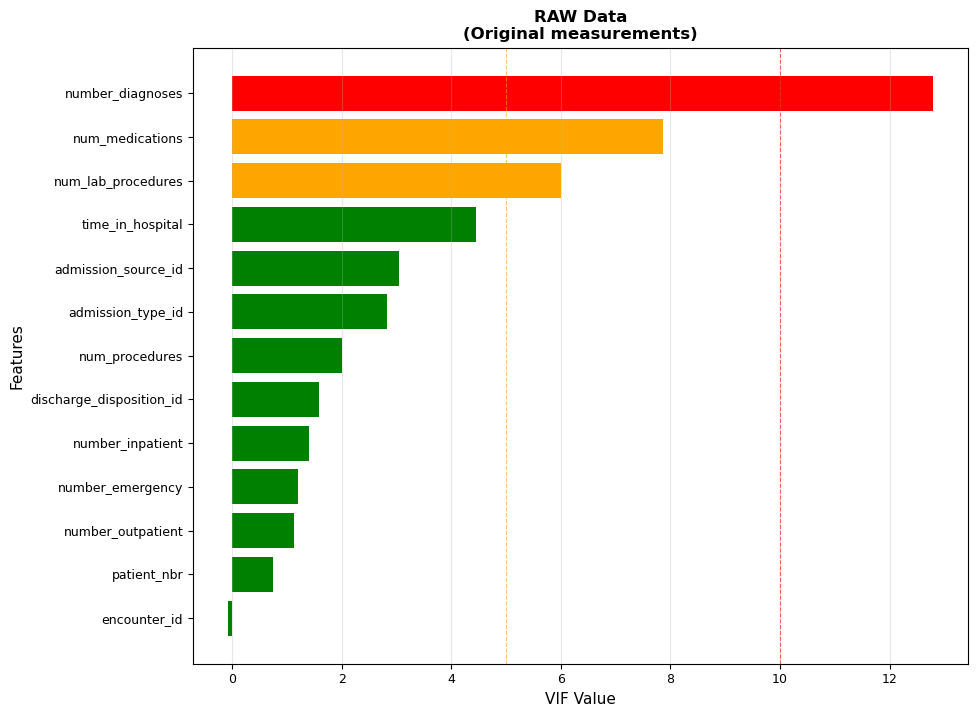

In [12]:
# Prepare RAW data for VIF calculation
X_vif_raw = df[common_features].copy()
X_vif_raw = X_vif_raw.loc[:, X_vif_raw.std() > 0]
if len(X_vif_raw) > 10000:
    X_vif_raw = X_vif_raw.sample(n=10000, random_state=34)
X_vif_raw = X_vif_raw.dropna()

# Calculate VIF for RAW data
vif_raw_data = []
for i, col in enumerate(X_vif_raw.columns):
    try:
        vif = variance_inflation_factor(X_vif_raw.values, i)
        vif_raw_data.append({'Feature': col, 'VIF': vif})
    except:
        vif_raw_data.append({'Feature': col, 'VIF': np.nan})

vif_raw_df = pd.DataFrame(vif_raw_data).sort_values('VIF', ascending=False)

# Plot RAW data VIF (all features since we filtered to common ones)

fig, ax1 = plt.subplots(1, 1, figsize=(10, 8))
colors_raw = ['red' if x > 10 else 'orange' if x > 5 else 'green' 
              for x in vif_raw_df['VIF'].fillna(0)]
ax1.barh(vif_raw_df['Feature'], vif_raw_df['VIF'], color=colors_raw)
ax1.set_xlabel('VIF Value', fontsize=11)
ax1.set_ylabel('Features', fontsize=11)
ax1.set_title('RAW Data\n(Original measurements)', fontsize=12, fontweight='bold')
ax1.axvline(x=5, color='orange', linestyle='--', linewidth=0.8, alpha=0.6)
ax1.axvline(x=10, color='red', linestyle='--', linewidth=0.8, alpha=0.6)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)
ax1.tick_params(axis='both', labelsize=9)

plt.show()

### 2.1.3 Kurtosis Analysis

KURTOSIS COMPARISON: RAW vs RAHIL vs COLIN

1. Raw Data:
   Total features: 13
   Mean kurtosis: 105.718
   Heavy-tailed (kurtosis > 3): 5
   Light-tailed (kurtosis < -1): 0

2. Rahil's Processed Data:
   Total features: 42
   Mean kurtosis: 4758.364
   Heavy-tailed (kurtosis > 3): 26
   Light-tailed (kurtosis < -1): 4

3. Colin's Dev Processed Data:
   Total features: 68
   Mean kurtosis: 2428.999
   Heavy-tailed (kurtosis > 3): 38
   Light-tailed (kurtosis < -1): 9


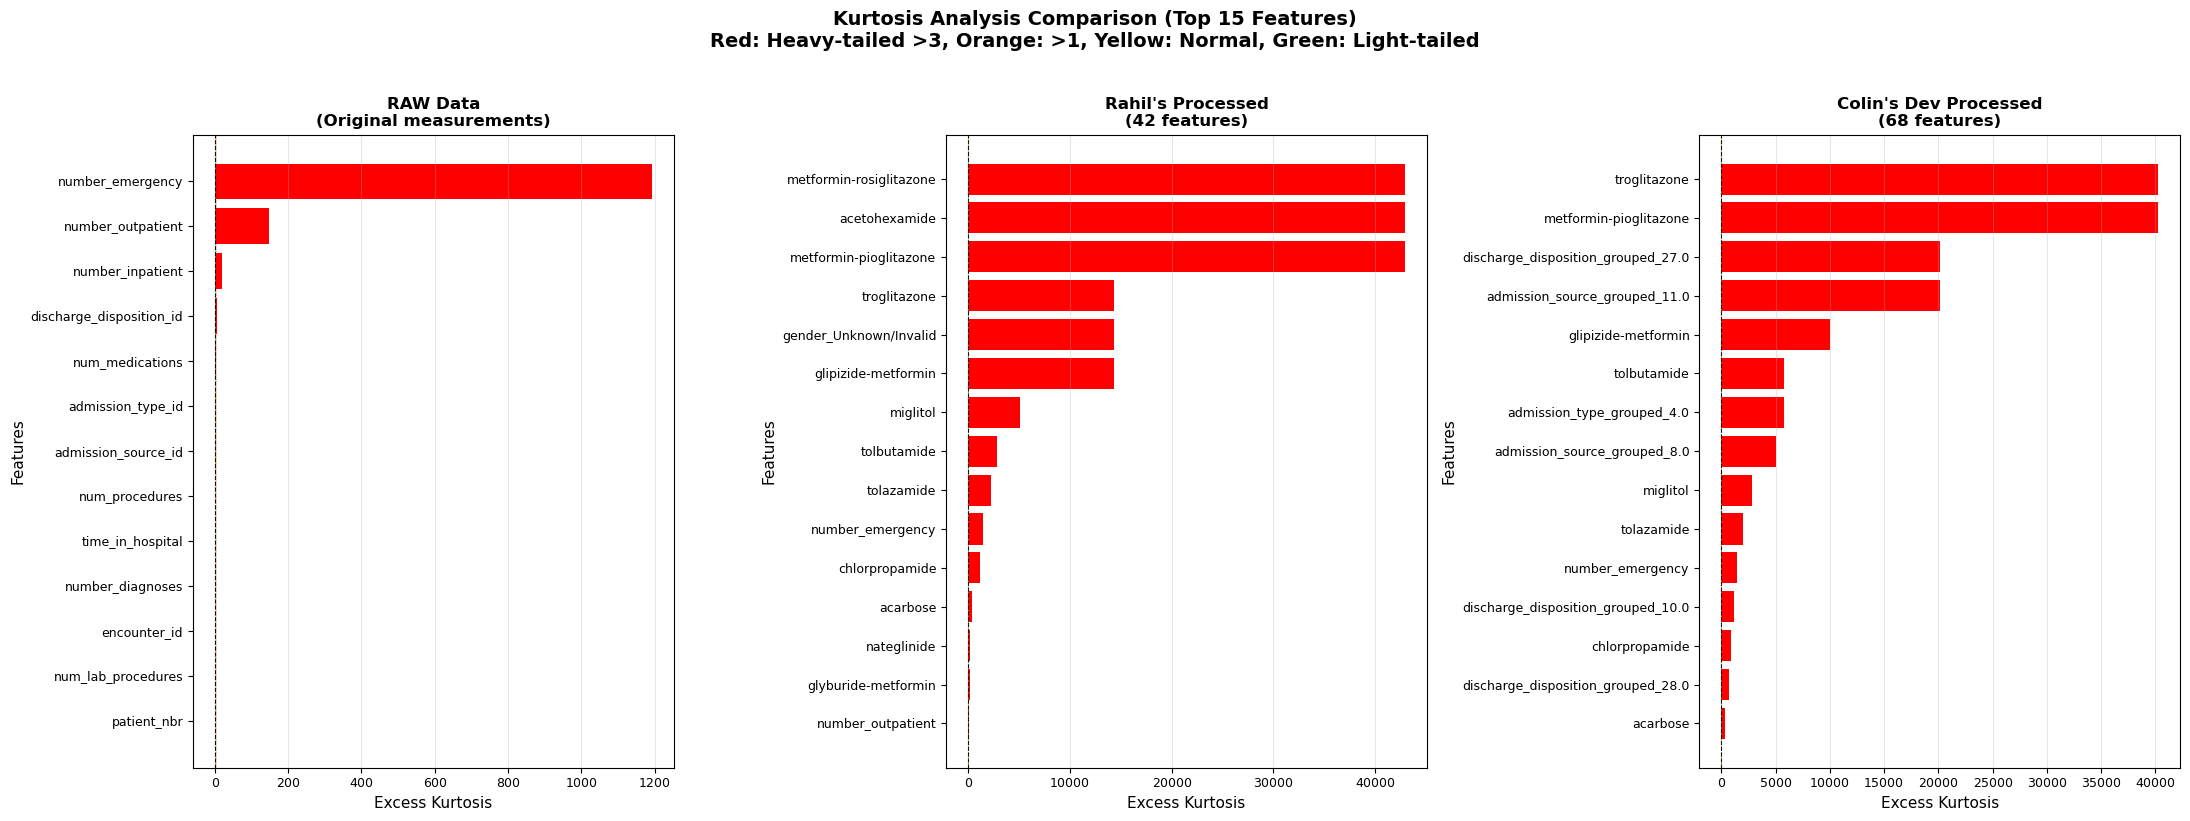

In [13]:
from scipy.stats import kurtosis

# Calculate kurtosis for RAW data (Fisher's definition: excess kurtosis)
kurtosis_raw = []
for col in raw_numerical_cols:
    kurt_value = kurtosis(df[col].dropna(), fisher=True)
    kurtosis_raw.append({'Feature': col, 'Kurtosis': kurt_value})

kurtosis_raw_df = pd.DataFrame(kurtosis_raw).sort_values('Kurtosis', ascending=False)

# Calculate kurtosis for RAHIL's TRAINING data
kurtosis_rahil = []
for col in rahil_numerical_cols:
    kurt_value = kurtosis(df_train[col].dropna(), fisher=True)
    kurtosis_rahil.append({'Feature': col, 'Kurtosis': kurt_value})
kurtosis_rahil_df = pd.DataFrame(kurtosis_rahil).sort_values('Kurtosis', ascending=False)

# Calculate kurtosis for COLIN's dev TRAINING data
kurtosis_colin = []
for col in colin_numerical_cols:
    kurt_value = kurtosis(df_train_dev[col].dropna(), fisher=True)
    kurtosis_colin.append({'Feature': col, 'Kurtosis': kurt_value})
kurtosis_colin_df = pd.DataFrame(kurtosis_colin).sort_values('Kurtosis', ascending=False)

# Comparison statistics
print("="*80)
print("KURTOSIS COMPARISON: RAW vs RAHIL vs COLIN")
print("="*80)
print(f"\n1. Raw Data:")
print(f"   Total features: {len(kurtosis_raw_df)}")
print(f"   Mean kurtosis: {kurtosis_raw_df['Kurtosis'].mean():.3f}")
print(f"   Heavy-tailed (kurtosis > 3): {(kurtosis_raw_df['Kurtosis'] > 3).sum()}")
print(f"   Light-tailed (kurtosis < -1): {(kurtosis_raw_df['Kurtosis'] < -1).sum()}")

print(f"\n2. Rahil's Processed Data:")
print(f"   Total features: {len(kurtosis_rahil_df)}")
print(f"   Mean kurtosis: {kurtosis_rahil_df['Kurtosis'].mean():.3f}")
print(f"   Heavy-tailed (kurtosis > 3): {(kurtosis_rahil_df['Kurtosis'] > 3).sum()}")
print(f"   Light-tailed (kurtosis < -1): {(kurtosis_rahil_df['Kurtosis'] < -1).sum()}")

print(f"\n3. Colin's Dev Processed Data:")
print(f"   Total features: {len(kurtosis_colin_df)}")
print(f"   Mean kurtosis: {kurtosis_colin_df['Kurtosis'].mean():.3f}")
print(f"   Heavy-tailed (kurtosis > 3): {(kurtosis_colin_df['Kurtosis'] > 3).sum()}")
print(f"   Light-tailed (kurtosis < -1): {(kurtosis_colin_df['Kurtosis'] < -1).sum()}")
print("="*80)

# Create three-panel comparison
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 8))

# Plot RAW data kurtosis (top 15)
top_kurt_raw = kurtosis_raw_df.head(15)
colors_raw = ['red' if x > 3 else 'orange' if x > 1 else 'yellow' if x > -1 else 'green' 
              for x in top_kurt_raw['Kurtosis']]
ax1.barh(top_kurt_raw['Feature'], top_kurt_raw['Kurtosis'], color=colors_raw)
ax1.set_xlabel('Excess Kurtosis', fontsize=11)
ax1.set_ylabel('Features', fontsize=11)
ax1.set_title('RAW Data\n(Original measurements)', fontsize=12, fontweight='bold')
ax1.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax1.axvline(x=3, color='red', linestyle=':', linewidth=0.6, alpha=0.5)
ax1.axvline(x=-1, color='green', linestyle=':', linewidth=0.6, alpha=0.5)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)
ax1.tick_params(axis='both', labelsize=9)

# Plot RAHIL's processed data kurtosis (top 15)
top_kurt_rahil = kurtosis_rahil_df.head(15)
colors_rahil = ['red' if x > 3 else 'orange' if x > 1 else 'yellow' if x > -1 else 'green' 
                for x in top_kurt_rahil['Kurtosis']]
ax2.barh(top_kurt_rahil['Feature'], top_kurt_rahil['Kurtosis'], color=colors_rahil)
ax2.set_xlabel('Excess Kurtosis', fontsize=11)
ax2.set_ylabel('Features', fontsize=11)
ax2.set_title("Rahil's Processed\n(42 features)", fontsize=12, fontweight='bold')
ax2.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax2.axvline(x=3, color='red', linestyle=':', linewidth=0.6, alpha=0.5)
ax2.axvline(x=-1, color='green', linestyle=':', linewidth=0.6, alpha=0.5)
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)
ax2.tick_params(axis='both', labelsize=9)

# Plot COLIN's dev processed data kurtosis (top 15)
top_kurt_colin = kurtosis_colin_df.head(15)
colors_colin = ['red' if x > 3 else 'orange' if x > 1 else 'yellow' if x > -1 else 'green' 
                for x in top_kurt_colin['Kurtosis']]
ax3.barh(top_kurt_colin['Feature'], top_kurt_colin['Kurtosis'], color=colors_colin)
ax3.set_xlabel('Excess Kurtosis', fontsize=11)
ax3.set_ylabel('Features', fontsize=11)
ax3.set_title("Colin's Dev Processed\n(68 features)", fontsize=12, fontweight='bold')
ax3.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax3.axvline(x=3, color='red', linestyle=':', linewidth=0.6, alpha=0.5)
ax3.axvline(x=-1, color='green', linestyle=':', linewidth=0.6, alpha=0.5)
ax3.invert_yaxis()
ax3.grid(axis='x', alpha=0.3)
ax3.tick_params(axis='both', labelsize=9)

fig.suptitle('Kurtosis Analysis Comparison (Top 15 Features)\nRed: Heavy-tailed >3, Orange: >1, Yellow: Normal, Green: Light-tailed', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

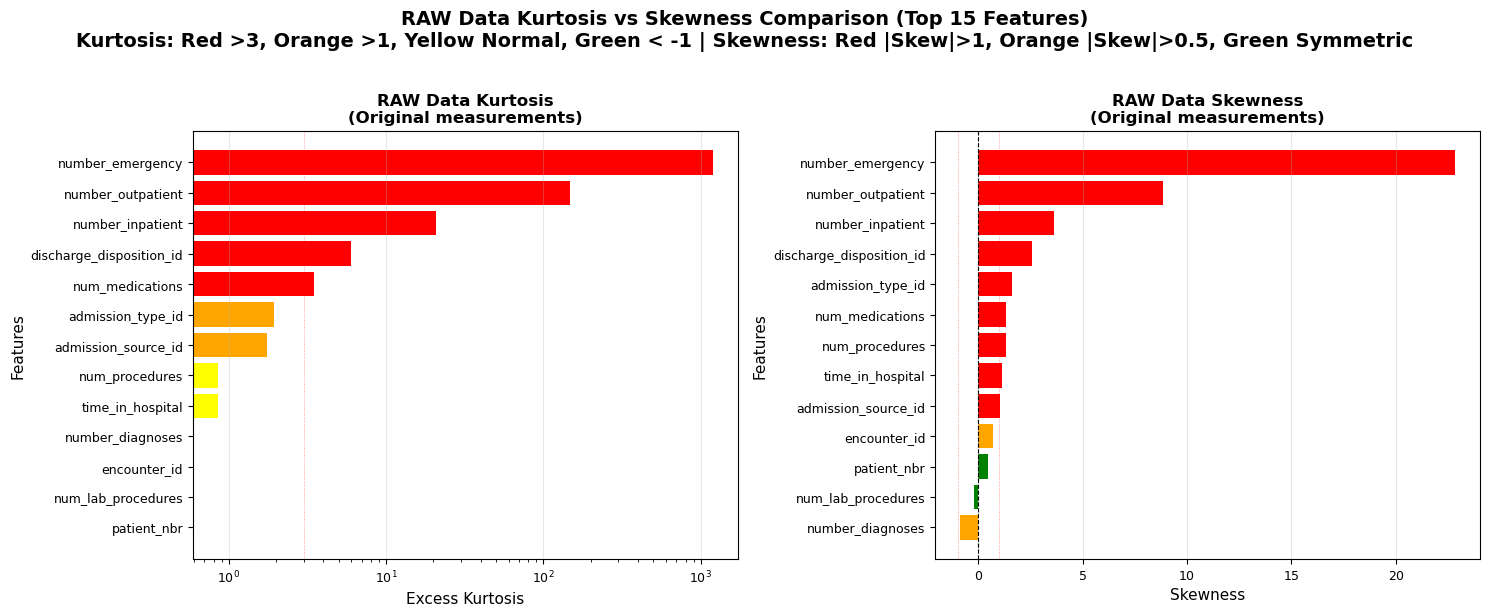

In [14]:
# Plot Just Raw Data Kurtosis and Skewness Side by Side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
# Plot RAW data kurtosis (top 15) - use log scale for better visibility 
top_kurt_raw = kurtosis_raw_df.head(15)
colors_raw_kurt = ['red' if x > 3 else 'orange' if x > 1 else 'yellow' if x > -1 else 'green' 
              for x in top_kurt_raw['Kurtosis']]
ax1.barh(top_kurt_raw['Feature'], top_kurt_raw['Kurtosis'], color=colors_raw_kurt)
ax1.set_xlabel('Excess Kurtosis', fontsize=11)
ax1.set_ylabel('Features', fontsize=11)
ax1.set_xscale('log')
ax1.set_title('RAW Data Kurtosis\n(Original measurements)', fontsize=12, fontweight='bold')
ax1.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax1.axvline(x=3, color='red', linestyle=':', linewidth=0.6, alpha=0.5)
ax1.axvline(x=-1, color='green', linestyle=':', linewidth=0.6, alpha=0.5)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)
ax1.tick_params(axis='both', labelsize=9)
# Plot RAW data skewness (top 15)
top_skew_raw = skewness_raw_df.head(15)
colors_raw_skew = ['red' if abs(x) > 1 else 'orange' if abs(x) > 0.5 else 'green' 
              for x in top_skew_raw['Skewness']]
ax2.barh(top_skew_raw['Feature'], top_skew_raw['Skewness'], color=colors_raw_skew)
ax2.set_xlabel('Skewness', fontsize=11)
ax2.set_ylabel('Features', fontsize=11)
ax2.set_title('RAW Data Skewness\n(Original measurements)', fontsize=12, fontweight='bold')
ax2.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax2.axvline(x=1, color='red', linestyle=':', linewidth=0.6, alpha=0.5)
ax2.axvline(x=-1, color='red', linestyle=':', linewidth=0.6, alpha=0.5)
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)
ax2.tick_params(axis='both', labelsize=9)   
fig.suptitle('RAW Data Kurtosis vs Skewness Comparison (Top 15 Features)\nKurtosis: Red >3, Orange >1, Yellow Normal, Green < -1 | Skewness: Red |Skew|>1, Orange |Skew|>0.5, Green Symmetric', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. Transformer Model 

### 3.0 Custom Loss Functions and Metrics

In [15]:
class FocalLoss(keras.losses.Loss):
    """
    Focal Loss for binary classification.
    
    Focal loss addresses class imbalance by down-weighting easy examples 
    and focusing on hard, misclassified examples.
    
    FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)
    
    Args:
        alpha: Weighting factor in range (0,1) to balance positive/negative examples
        gamma: Focusing parameter for modulating loss (gamma >= 0)
    """
    def __init__(self, alpha=0.25, gamma=2.0, **kwargs):
        super().__init__(**kwargs)
        self.alpha = alpha
        self.gamma = gamma
    
    def call(self, y_true, y_pred):
        # Clip predictions to prevent log(0)
        y_pred = tf.clip_by_value(y_pred, keras.backend.epsilon(), 1 - keras.backend.epsilon())
        
        # Calculate cross entropy
        cross_entropy = -y_true * tf.math.log(y_pred)
        
        # Calculate focal loss
        loss = self.alpha * tf.pow(1 - y_pred, self.gamma) * cross_entropy
        
        return tf.reduce_mean(loss)
    
    def get_config(self):
        config = super().get_config()
        config.update({
            "alpha": self.alpha,
            "gamma": self.gamma,
        })
        return config


class F1Score(keras.metrics.Metric):
    """
    Custom F1 Score metric for binary classification.
    
    F1 = 2 * (precision * recall) / (precision + recall)
    """
    def __init__(self, name='f1_score', threshold=0.5, **kwargs):
        super().__init__(name=name, **kwargs)
        self.threshold = threshold
        self.true_positives = self.add_weight(name='tp', initializer='zeros')
        self.false_positives = self.add_weight(name='fp', initializer='zeros')
        self.false_negatives = self.add_weight(name='fn', initializer='zeros')
    def update_state(self, y_true, y_pred, sample_weight=None):
        # Convert predictions to binary using threshold
        y_pred = tf.cast(y_pred >= self.threshold, tf.float32)
        y_true = tf.cast(y_true, tf.float32)
        
        # Calculate true positives, false positives, false negatives
        tp = tf.reduce_sum(y_true * y_pred)
        fp = tf.reduce_sum((1 - y_true) * y_pred)
        fn = tf.reduce_sum(y_true * (1 - y_pred))
        
        self.true_positives.assign_add(tp)
        self.false_positives.assign_add(fp)
        self.false_negatives.assign_add(fn)
    
    def result(self):
        precision = self.true_positives / (self.true_positives + self.false_positives + keras.backend.epsilon())
        recall = self.true_positives / (self.true_positives + self.false_negatives + keras.backend.epsilon())
        f1 = 2 * (precision * recall) / (precision + recall + keras.backend.epsilon())
        return f1
    
    def reset_state(self):
        self.true_positives.assign(0)
        self.false_positives.assign(0)
        self.false_negatives.assign(0)
    
    def get_config(self):
        config = super().get_config()
        config.update({"threshold": self.threshold})
        return config


def calculate_class_weights(y_train):
    """
    Calculate class weights for imbalanced datasets.
    
    Args:
        y_train: Training labels
        
    Returns:
        Dictionary of class weights
    """
    from sklearn.utils.class_weight import compute_class_weight
    
    classes = np.unique(y_train)
    weights = compute_class_weight('balanced', classes=classes, y=y_train.ravel())
    class_weights = dict(zip(classes, weights))
    
    print(f"Calculated class weights: {class_weights}")
    return class_weights

In [16]:
def build_transformer_model(
    input_shape: int,
    num_classes: int = 2,
    embedding_dim: int = 192,
    num_heads: int = 8,
    key_dim: int = 24,
    ffn_dim: int = 2048,
    dense_dim: int = 64,
):
    """
    Build a transformer model for readmission prediction.

    Args:
        input_shape: Number of input features
        num_classes: Number of output classes
        embedding_dim: Dimension of embedding layer
        num_heads: Number of attention heads
        key_dim: Dimension of key in attention
        ffn_dim: Dimension of feed-forward network
        dense_dim: Dimension of final dense layer

    Returns:
        Compiled Keras model
    """

    inputs = keras.Input(shape=(input_shape,))

    # Embedding layer
    x = keras.layers.Dense(
        embedding_dim, activation="relu", kernel_regularizer=keras.regularizers.l2(0.01)
    )(inputs)
    x = keras.layers.Reshape((1, embedding_dim))(x)

    # Dropout layer
    x = keras.layers.Dropout(0.1)(x)

    # Transformer block
    attention_output = keras.layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=key_dim
    )(x, x)
    x = keras.layers.Add()([x, attention_output])
    x = keras.layers.LayerNormalization()(x)

    # Feed-forward network
    ffn_output = keras.layers.Dense(
        ffn_dim, activation="relu", kernel_regularizer=keras.regularizers.l2(0.01)
    )(x)
    ffn_output = keras.layers.Dense(
        embedding_dim, kernel_regularizer=keras.regularizers.l2(0.01)
    )(ffn_output)
    x = keras.layers.Add()([x, ffn_output])
    x = keras.layers.LayerNormalization()(x)

    # Pooling layer
    x = keras.layers.GlobalAveragePooling1D()(x)

    # Dropout layer
    x = keras.layers.Dropout(0.1)(x)

    # Output layers
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(
        dense_dim, activation="relu", kernel_regularizer=keras.regularizers.l2(0.01)
    )(x)
    outputs = keras.layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

In [17]:
def train_transformer_model(
    X_train: pd.DataFrame,
    Y_train: pd.Series,
    X_val: pd.DataFrame,
    Y_val: pd.Series,
    epochs: int = 10,
    batch_size: int = 64,
    verbose: int = 1,
    use_focal_loss: bool = True,
    use_class_weights: bool = True,
):
    """
    Train a transformer model for readmission prediction.

    Args:
        X_train: Training features
        Y_train: Training target
        X_val: Validation features
        Y_val: Validation target
        epochs: Number of training epochs
        batch_size: Batch size for training
        verbose: Verbosity level (0, 1, or 2)
        use_focal_loss: Whether to use focal loss (default: True)
        use_class_weights: Whether to use class weights (default: True)

    Returns:
        Tuple of (trained model, training history)
    """

    early_stopping_callback = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        min_delta=0.001,
        patience=5,
        verbose=1,
        mode="min",
        restore_best_weights=True,
    )

    input_shape = X_train.shape[1]
    num_classes = len(np.unique(Y_train))

    model = build_transformer_model(input_shape, num_classes)

    # Choose loss function
    if use_focal_loss:
        loss_fn = FocalLoss(alpha=0.25, gamma=2.0)
        print("Using Focal Loss to address class imbalance")
    else:
        loss_fn = "binary_crossentropy"
        print("Using Binary Crossentropy Loss")

    # Calculate class weights if requested
    class_weights = None
    if use_class_weights:
        class_weights = calculate_class_weights(Y_train)

    # Compile model with F1 Score metric
    model.compile(
        optimizer="adam",
        loss=loss_fn,
        metrics=["accuracy", F1Score(threshold=0.5)],
    )

    # Fit model
    history = model.fit(
        X_train,
        Y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val, Y_val),
        class_weight=class_weights,
        callbacks=[early_stopping_callback],
        verbose=verbose,
    )

    return model, history

In [18]:
def plot_training_history(history, title_prefix="Model"):
    """
    Plot training and validation metrics over epochs.

    Args:
        history: Keras History object from model training
        title_prefix: Prefix for plot titles
    """
    # Check if F1 score is in history
    has_f1 = 'f1_score' in history.history
    
    if has_f1:
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
    else:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Plot accuracy
    ax1.plot(history.history["accuracy"], label="Train Accuracy")
    ax1.plot(history.history["val_accuracy"], label="Val Accuracy")
    ax1.set_title(f"{title_prefix} Accuracy")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Plot loss
    ax2.plot(history.history["loss"], label="Train Loss")
    ax2.plot(history.history["val_loss"], label="Val Loss")
    ax2.set_title(f"{title_prefix} Loss")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.legend()
    ax2.grid(alpha=0.3)

    # Plot F1 score if available
    if has_f1:
        ax3.plot(history.history["f1_score"], label="Train F1 Score")
        ax3.plot(history.history["val_f1_score"], label="Val F1 Score")
        ax3.set_title(f"{title_prefix} F1 Score")
        ax3.set_xlabel("Epoch")
        ax3.set_ylabel("F1 Score")
        ax3.legend()
        ax3.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

**Model Configuration:**
- Loss Function: Binary Crossentropy
- Class Weights: Enabled (automatically calculated ~10:1 ratio)
- Focal Loss: Disabled (testing showed it caused model collapse when combined with class weights)
- Metrics: Accuracy + F1 Score

In [19]:
# Train the transformer model on Rahil's data splits
# Using class weights only (no focal loss) as it provided better prediction variation
model_rahil, history_rahil = train_transformer_model(
    X_train=df_train[df_train.columns.difference(["readmitted"])],
    Y_train=df_train["readmitted"],
    X_val=df_val[df_val.columns.difference(["readmitted"])],
    Y_val=df_val["readmitted"],
    epochs=10,
    batch_size=64,
    verbose=1,
    use_focal_loss=False,
    use_class_weights=True,
)

I0000 00:00:1765170181.929689  136385 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-12-07 21:03:01.930105: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2343] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Using Binary Crossentropy Loss
Calculated class weights: {0: 0.5483986401860798, 1: 5.6654343807763405}
Epoch 1/10
671/671 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.5443 - f1_score: 0.1518 - loss: 1.4255 - val_accuracy: 0.0881 - val_f1_score: 0.1619 - val_loss: 0.8619
Epoch 2/10
671/671 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.5210 - f1_score: 0.1640 - loss: 0.7028 - val_accuracy: 0.1102 - val_f1_score: 0.1643 - val_loss: 0.7308
Epoch 3/10
671/671 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.4452 - f1_score: 0.1608 - loss: 0.6946 - val_accuracy: 0.7466 - val_f1_score: 0.1568 - val_loss: 0.6651
Epoch 4/10
671/671 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.5445 - f1_score: 0.1669 - loss: 0.6934 - val_accuracy: 0.6174 - val_f1_score: 0.1702 - val_loss: 0.6669
Epoch 5/10
671/671 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.2128 - f1_score: 0.1589 - loss: 0.6955 - val_accuracy: 0.0881 - val_f1_score: 0.1619 - val_loss: 0.7196
Epoch 6/10
671/671 ━━━━━━━━━━━━━━━━━

### 3.1 Train on Rahil's Data Splits

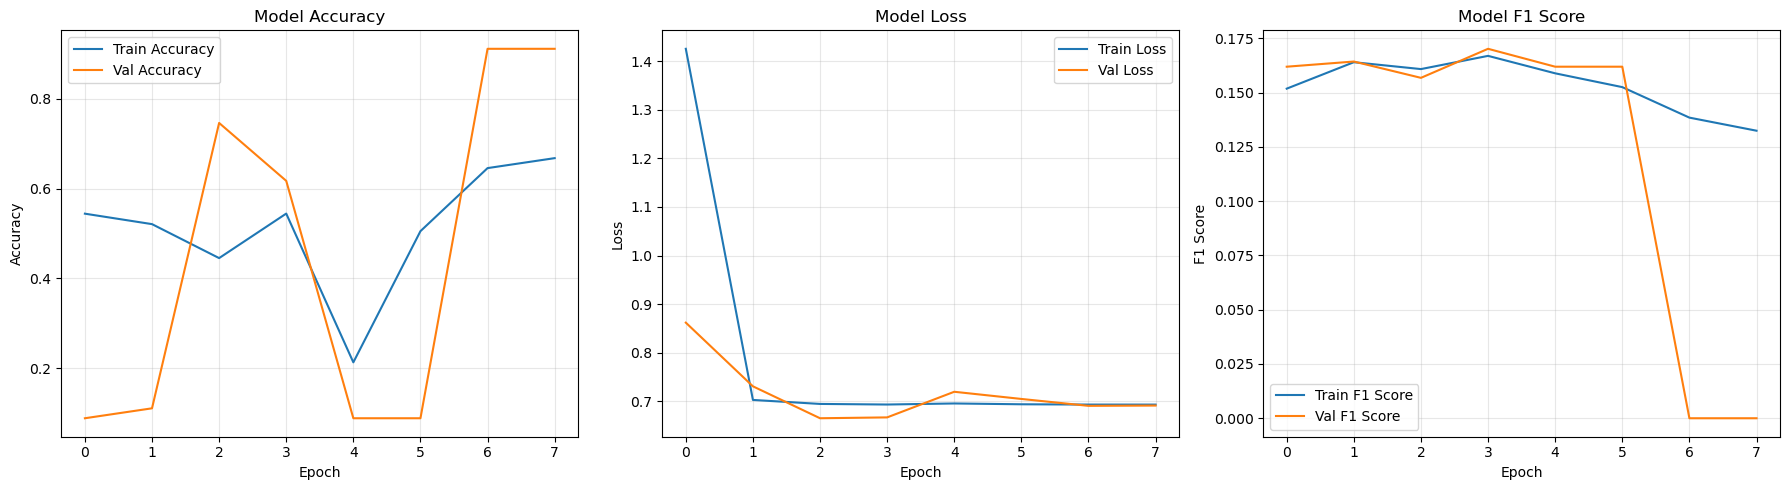

In [20]:
# Plot training history for Rahil's data
plot_training_history(history_rahil)

In [21]:
# Evaluate on Rahil's test set
eval_results_rahil = model_rahil.evaluate(
    df_test[df_test.columns.difference(["readmitted"])],
    df_test["readmitted"],
    verbose=1,
)
test_loss_rahil, test_accuracy_rahil, test_f1_rahil = eval_results_rahil
print(
    f"\nRahil's Data - Test Loss: {test_loss_rahil:.4f}, Test Accuracy: {test_accuracy_rahil:.4f}, Test F1: {test_f1_rahil:.4f}"
)

447/447 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7356 - f1_score: 0.1424 - loss: 0.6658

Rahil's Data - Test Loss: 0.6658, Test Accuracy: 0.7356, Test F1: 0.1424


### 3.2 Train on Colin's Dev Data Splits

In [22]:
# Train the transformer model on Colin's dev data splits
# Using class weights only (no focal loss) as it provided better prediction variation
model_colin_dev, history_colin_dev = train_transformer_model(
    X_train=df_train_dev,
    Y_train=df_y_train_dev.values.ravel(),
    X_val=df_val_dev,
    Y_val=df_y_val_dev.values.ravel(),
    epochs=10,
    batch_size=64,
    verbose=1,

    use_focal_loss=False,
    use_class_weights=True)

Using Binary Crossentropy Loss
Calculated class weights: {0: 0.5501626527432274, 1: 5.483787465940054}
Epoch 1/10
629/629 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.4821 - f1_score: 0.1573 - loss: 1.3398 - val_accuracy: 0.9061 - val_f1_score: 0.0058 - val_loss: 0.6947
Epoch 2/10
629/629 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.5354 - f1_score: 0.1553 - loss: 0.7049 - val_accuracy: 0.0912 - val_f1_score: 0.1670 - val_loss: 0.7174
Epoch 3/10
629/629 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.1008 - f1_score: 0.1665 - loss: 0.6941 - val_accuracy: 0.0912 - val_f1_score: 0.1670 - val_loss: 0.6945
Epoch 4/10
629/629 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.3915 - f1_score: 0.1576 - loss: 0.6933 - val_accuracy: 0.0912 - val_f1_score: 0.1670 - val_loss: 0.6933
Epoch 5/10
629/629 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.6517 - f1_score: 0.1418 - loss: 0.6932 - val_accuracy: 0.0912 - val_f1_score: 0.1670 - val_loss: 0.6951
Epoch 6/10
629/629 ━━━━━━━━━━━━━━━━━━

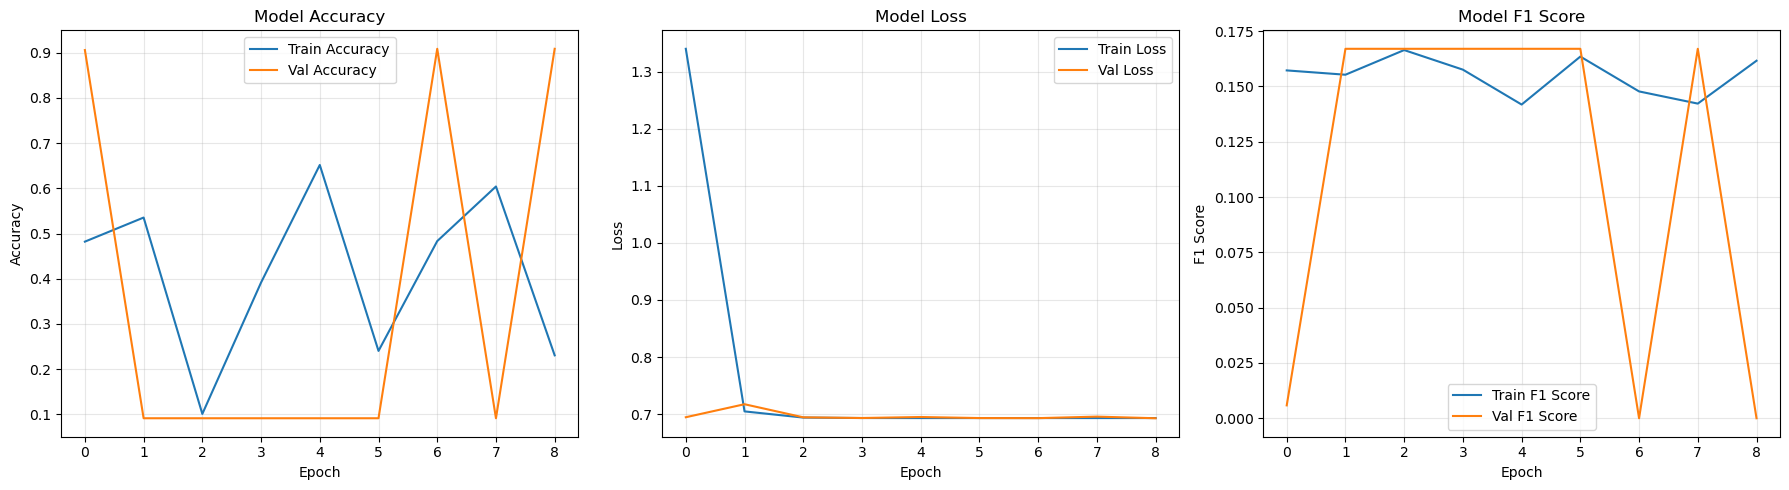

In [23]:
# Plot training history for Colin's dev data
plot_training_history(history_colin_dev)

In [24]:
# Evaluate on Colin's dev test set
eval_results_colin_dev = model_colin_dev.evaluate(
    df_test_dev, df_y_test_dev.values.ravel(), verbose=1
)
test_loss_colin_dev, test_accuracy_colin_dev, test_f1_colin_dev = eval_results_colin_dev
print(
    f"\nColin's Dev Data - Test Loss: {test_loss_colin_dev:.4f}, Test Accuracy: {test_accuracy_colin_dev:.4f}, Test F1: {test_f1_colin_dev:.4f}"
)

420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0911 - f1_score: 0.1671 - loss: 0.6933

Colin's Dev Data - Test Loss: 0.6933, Test Accuracy: 0.0911, Test F1: 0.1671


### 3.3 Compare Results: Rahil's vs Colin's Data Processing

In [25]:
# Calculate metrics for both models
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

# Predictions for Rahil's data
Y_pred_rahil_proba = model_rahil.predict(
    df_test[df_test.columns.difference(["readmitted"])]
)
Y_pred_rahil = (Y_pred_rahil_proba > 0.5).astype(int).ravel()
Y_true_rahil = df_test["readmitted"].values

# Predictions for Colin's dev data
Y_pred_colin_dev_proba = model_colin_dev.predict(df_test_dev)
Y_pred_colin_dev = (Y_pred_colin_dev_proba > 0.5).astype(int).ravel()
Y_true_colin_dev = df_y_test_dev.values.ravel()

# Calculate metrics
metrics_comparison = pd.DataFrame(
    {
        "Data Source": ["Rahil's Processing", "Colin's Dev Processing"],
        "Test Accuracy": [
            accuracy_score(Y_true_rahil, Y_pred_rahil),
            accuracy_score(Y_true_colin_dev, Y_pred_colin_dev),
        ],
        "Precision": [
            precision_score(Y_true_rahil, Y_pred_rahil),
            precision_score(Y_true_colin_dev, Y_pred_colin_dev),
        ],
        "Recall": [
            recall_score(Y_true_rahil, Y_pred_rahil),
            recall_score(Y_true_colin_dev, Y_pred_colin_dev),
        ],
        "F1 Score": [
            f1_score(Y_true_rahil, Y_pred_rahil),
            f1_score(Y_true_colin_dev, Y_pred_colin_dev),
        ],
        "Test Loss": [test_loss_rahil, test_loss_colin_dev],
    }
)

print("\n" + "=" * 70)
print("TRANSFORMER MODEL COMPARISON: Rahil's vs Colin's Data Processing")
print("=" * 70)
print(metrics_comparison.to_string(index=False))
print("=" * 70)

447/447 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

TRANSFORMER MODEL COMPARISON: Rahil's vs Colin's Data Processing
           Data Source  Test Accuracy  Precision   Recall  F1 Score  Test Loss
    Rahil's Processing       0.735598   0.099241 0.252006  0.142404   0.665795
Colin's Dev Processing       0.091146   0.091146 1.000000  0.167065   0.693300


### 3.5 Summary: Addressing Class Imbalance

**Techniques Implemented in Final Model:**

1. **Class Weights**: Automatically calculated (10:1 ratio) and applied to penalize misclassifications of the minority class more heavily
2. **F1 Score Metric**: Tracks model performance on the positive class during training
3. **Binary Crossentropy Loss**: Standard loss function that works well with class weights

**Why Not Focal Loss?**
- Testing revealed that **Focal Loss + Class Weights** caused model collapse (all predictions identical)
- **Class Weights alone** provided the best prediction variation and model performance



## 4. Notebook Exports

#### 4.1 Export models

In [26]:
# Export the transformer model (trained on Rahil's data) to results/
model_rahil.save("../results/transformer.h5")
print("Model saved to ../results/transformer.h5")

Model saved to ../results/transformer.h5


#### 4.2 Export visualizations

In [27]:
# Create visualizations only for combined cleaned data (which has all features)
kde_plots_combined = create_kde_plots(df_combined_clean, continuous_features)
box_plots_combined = create_box_plots(df_combined_clean, continuous_features)
violin_combined = create_violin_plots(df_combined_clean, continuous_features)

# Save visualizations to results directory
kde_plots_combined.save("../results/kde_plots_combined.html")
box_plots_combined.save("../results/box_plots_combined.html")
violin_combined.save("../results/violin_plots_combined.html")
print("Visualizations saved successfully!")

Visualizations saved successfully!
